In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [13]:
# load datablock
data_2010= pd.read_csv('movies_only_2010.csv')
data_2025= pd.read_csv('movies_only_2025.csv')



In [ ]:


def explode_data(dataframe):
    """
    Explodes entries with mulitple genres so every genre has own entrie
    """
   
    df = dataframe.copy()
       
    df['genres'] = df['genres'].astype(str).str.split(',')
    
    df_exploded = df.explode('genres')
    
    df_exploded['genres'] = df_exploded['genres'].str.strip()
    
    return df_exploded
    

In [ ]:
def pie_chart(dataframe,columname="genres",topgenres=5,filter_zero=False):
    """
    Shows genre distributuion for x amount of genres and sums up the rest
    """
    
    if filter_zero:
        if 'box_office_revenue' in dataframe.columns:
            dataframe = dataframe[dataframe['box_office_revenue']!= 0]

    # splitted multi genre movies into multiple entries with one genre
    genres_frame = explode_data(dataframe)

    allentries_count = genres_frame[columname].value_counts()
    #print(allentries_count)
    top_genres_plot = allentries_count.iloc[:topgenres]
    rest_genres_plot = allentries_count.iloc[topgenres:].sum()

    if rest_genres_plot > 0:
        rest_genres_series = pd.Series({'Rest': rest_genres_plot})
        plot_data = pd.concat([top_genres_plot,rest_genres_series])
    else:
        plot_data = top_genres_plot
    
    plt.figure(figsize=(9, 9))
    plot_data.plot(
        kind='pie', 
        autopct='%1.1f%%', 
        startangle=140, 
        colormap='Set3'
    )
    if filter_zero:
        filter_text= "Filterd out 0 box office movies"
        plt.title(f"Top {topgenres} Genres + Rest {filter_text}")
        plt.ylabel('')
    else:
        filter_text="all Movies Released"
        plt.title(f"Top {topgenres} Genres + Rest {filter_text}")
        plt.ylabel('')
        
    plt.show()

----
genres
Drama              278
Comedy             229
Action             123
Romance            112
Thriller           111
Adventure           73
Crime               68
Family              57
Fantasy             55
Horror              55
Mystery             47
Animation           43
Science Fiction     36
History             33
Documentary         28
Music               16
War                 15
Western              5
TV Movie             2
Not found            1
Name: count, dtype: int64


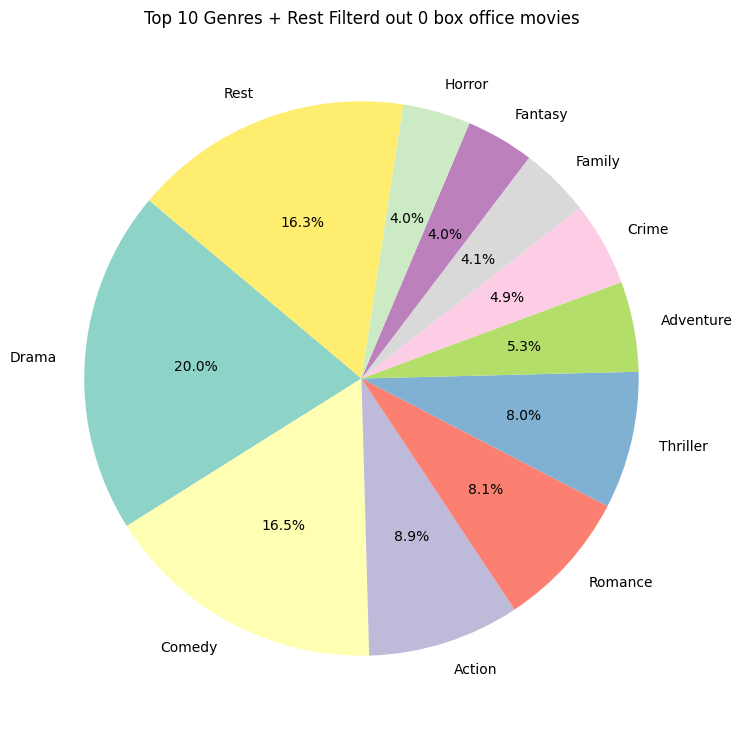

genres
Drama              231
Comedy             150
Thriller           147
Action             120
Horror              89
Crime               66
Romance             60
Fantasy             58
Adventure           55
Animation           50
Mystery             50
Family              43
Science Fiction     40
History             37
Music               24
War                 19
Documentary         16
Western              7
Name: count, dtype: int64


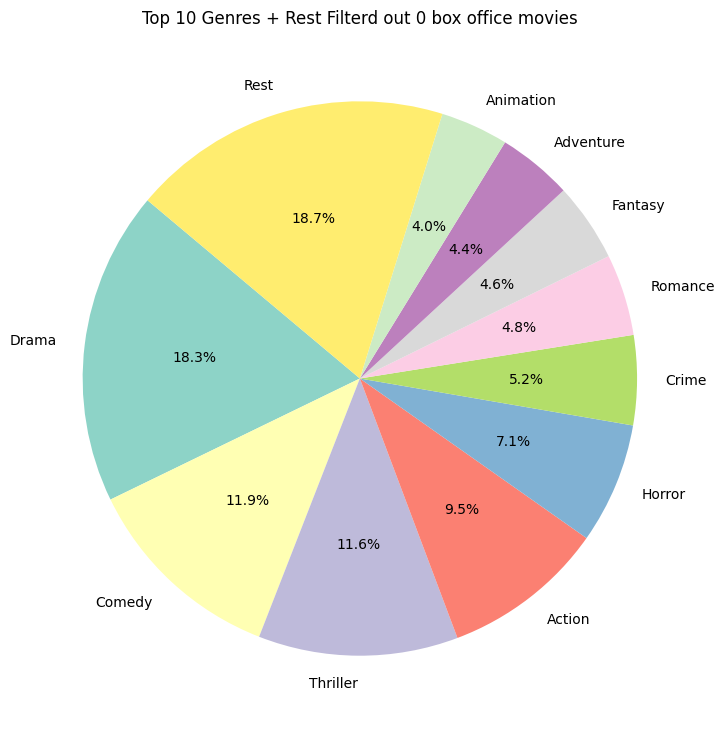

In [ ]:
#testblock

#pie_chart(data_2010,"genres",10,False)
#print("----")
#pie_chart(data_2010,"genres",10,True)
#pie_chart(data_2025,"genres",10,True)


#Growth compare

In [ ]:
def plot_growth(dataframe_old, dataframe_new, column='genres', year_old=2010,year_new=2025,filter_zero=True):
      """
      Shows Growth of genres from one time frame to another
      """

      if filter_zero:
            if 'box_office_revenue' in dataframe_old.columns:
                  dataframe_old = dataframe_old[dataframe_old['box_office_revenue']!= 0]
            if 'box_office_revenue' in dataframe_new.columns:
                  dataframe_new = dataframe_new[dataframe_new['box_office_revenue']!= 0]


      dataframe_old = explode_data(dataframe_old)
      dataframe_new = explode_data(dataframe_new)

      count_old = dataframe_old[column].value_counts()
      count_new = dataframe_new[column].value_counts()
      print(count_old)
      print("-----")
      print(count_new)

      #Merge
      dataframe_compare= pd.DataFrame({f'Year_{year_old}': count_old,f'Year_{year_new}': count_new}).fillna(0)

      dataframe_compare['Growth (%)'] = np.where(dataframe_compare[f'Year_{year_old}']== 0, 100.0, ((dataframe_compare[f'Year_{year_new}'] - dataframe_compare[f'Year_{year_old}']) / dataframe_compare[f'Year_{year_old}']) *100)
      dataframe_compare = dataframe_compare.sort_values(by = 'Growth (%)')

      plt.figure(figsize=(10,8))
      colorbar = ['#d62728' if x < 0 else '#2ca02c' for x in dataframe_compare['Growth (%)']]
      bar_plot = plt.barh(dataframe_compare.index,dataframe_compare['Growth (%)'], color = colorbar)
      plt.axvline(0,color='black', linewidth=1.5)

      for bar in bar_plot:
            bar_width = bar.get_width()
            x_poistion = bar_width + (2 if bar_width > 0 else- 2)
            direction = 'left' if bar_width > 0 else 'right'
            plt.text(x_poistion, bar.get_y() + bar.get_height()/2, f'{bar_width:+.1f}%', va = 'center' , ha=direction , color = 'black', fontsize=10)
      
      plt.tight_layout
      plt.show()


      

genres
Drama              278
Comedy             229
Action             123
Romance            112
Thriller           111
Adventure           73
Crime               68
Family              57
Fantasy             55
Horror              55
Mystery             47
Animation           43
Science Fiction     36
History             33
Documentary         28
Music               16
War                 15
Western              5
TV Movie             2
Not found            1
Name: count, dtype: int64
-----
genres
Drama              231
Comedy             150
Thriller           147
Action             120
Horror              89
Crime               66
Romance             60
Fantasy             58
Adventure           55
Animation           50
Mystery             50
Family              43
Science Fiction     40
History             37
Music               24
War                 19
Documentary         16
Western              7
Name: count, dtype: int64


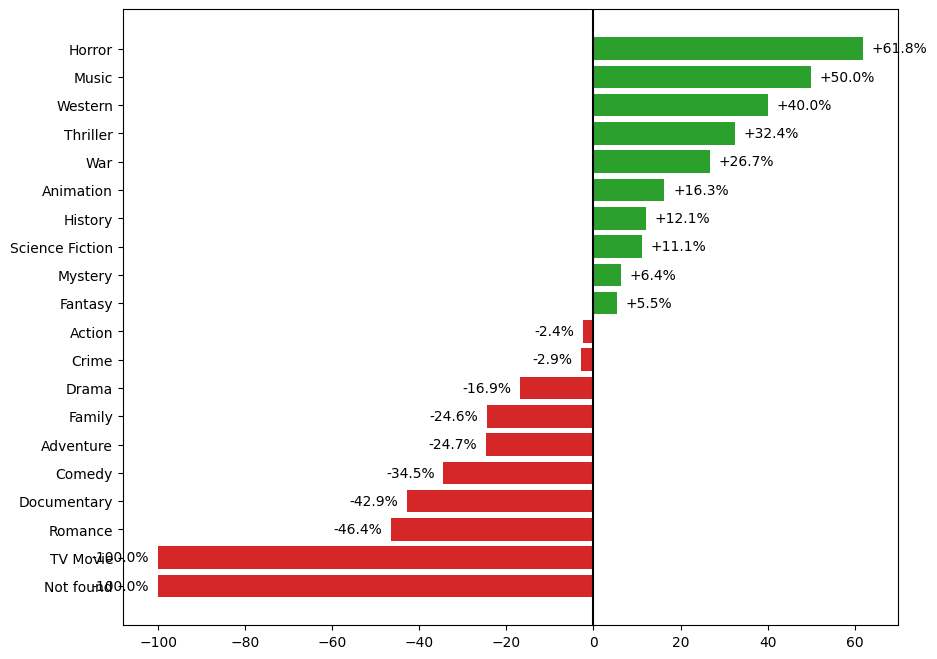

In [ ]:
#testblock growth
#plot_growth(data_2010,data_2025)

Financial Compare


In [ ]:
def plot_toal_boxoffice(dataframe_old, dataframe_new, year_old=2010 ,year_new=2025, box_office='box_office_revenue', inflation_factor=1.0):
    """
    Compares total box_office revenue of two timeframes
    """

    total_old = (dataframe_old[box_office].sum()* inflation_factor) /1000000000
    total_new = dataframe_new[box_office].sum() / 1000000000

    plt.figure(figsize=(7,6))
    bars = plt.bar([f'Year {year_old}', f'Year {year_new}'],[total_old, total_new], color=['#1f77b4','#ff7f0e'])

    if inflation_factor != 1.0:
        plt.title(f'Combined revenue (Inflation corrected for {year_old})', fontsize=14)
        plt.ylabel(f'Revenue in billion USD(For Year {year_new})', fontsize=12)
    else:
        plt.title('Combined revenue', fontsize=14)
        plt.ylabel('Revenue in billion USD', fontsize=12)

    plt.tight_layout()
    plt.show





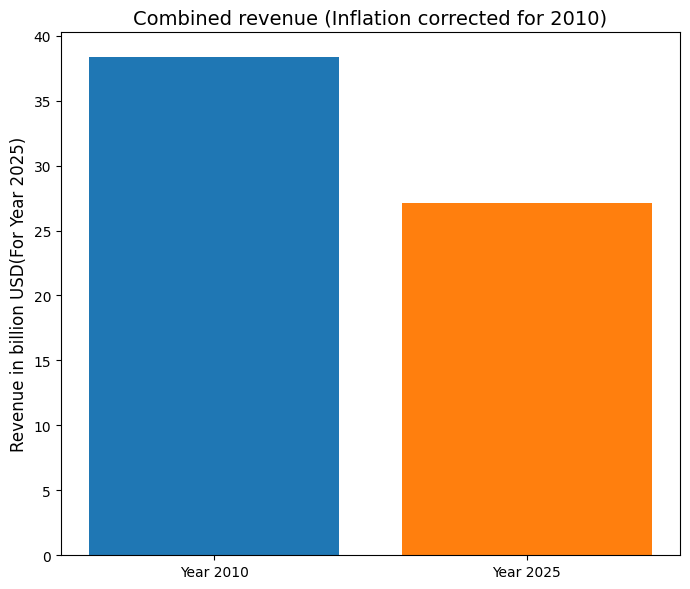

In [ ]:
#testblock total
#plot_toal_boxoffice(data_2010,data_2025,inflation_factor=1.45)

Genre Comparsion

In [ ]:
def plot_genre_comp(dataframe_old,dataframe_new,genre_list, year_old=2010,year_new=2025,column='genres', box_office='box_office_revenue',inflation_factor=1.45):
    """
    Comparses The financial success of same genres in different time frames
    """
    
    #split multi genre movies
    dataframe_old=explode_data(dataframe_old)
    dataframe_new=explode_data(dataframe_new)
    #filter moviegenres out
    dataframe_old_filterd= dataframe_old[dataframe_old[column].isin(genre_list)]
    dataframe_new_filterd= dataframe_new[dataframe_new[column].isin(genre_list)]
    #calculate genre revenue
    box_old = (dataframe_old_filterd.groupby(column)[box_office].sum() * inflation_factor / 1000000)
    box_new = (dataframe_new_filterd.groupby(column)[box_office].sum()  / 1000000)

    dataframe_revenue = pd.DataFrame({f'{year_old}': box_old,f'{year_new}':box_new}).fillna(0)


    axes = dataframe_revenue.plot(kind='bar',figsize=(10,6),color=['#1f77b4', '#ff7f0e'], width=0.7)
    plt.title(f'Finacial Comparrision between genres',fontsize=15)
    plt.ylabel('Revenue in Million USD')
    plt.xlabel('')

    plt.xticks(rotation=0,fontsize=11)
    plt.grid(axis='y',linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show
               
    

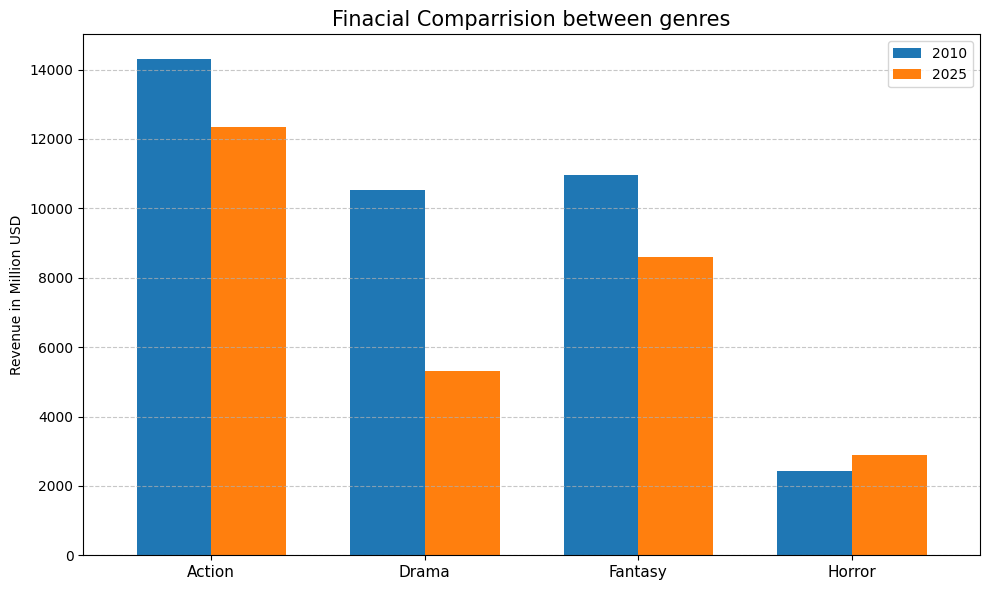

In [ ]:
#testblock genre comp
#genres= ['Action','Fantasy','Drama','Horror']
#plot_genre_comp(data_2010,data_2025,genres,inflation_factor=1.45)